# Credit Risk Scoring Project - Decision Trees & Ensemble Learning

## Data Cleaning & Preparation
- Downloading datasets
- Re-encoding categorical variables
- Doing the train/validation/test split

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

#%matplotlib inline

In [2]:
# !wget "https://raw.githubusercontent.com/gastonstat/CreditScoring/refs/heads/master/CreditScoring.csv"

df = pd.read_csv('CreditScoring.csv')      # na_values= ['0', '99999999']   # 0 and 99999999 were coded as na in the data manual
df.columns = df.columns.str.lower()
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [3]:
df.isnull().sum()

status       0
seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

## Categorical Variables

In [4]:
# status
df.status.unique()
print(df.status.value_counts())
df.status = df.status.map({1:'good', 2:'default', 0:'unknown'}) #unknown
print(df.status.value_counts())

# Home
df.home = df.home.map({1:'rent', 2:'owner', 3:'private', 4:'ignore', 5:'parents', 6:'other', 0:'unknown'}) #unknown
print(df.home.value_counts())

#Marital
df.marital = df.marital.map({1:'single', 2:'married', 3:'widow', 4:'separated', 5:'divorced', 0:'unknown'}) #unknown
print(df.marital.value_counts())

# Records 
print(df.records.value_counts())
df.records.unique()
df.records = df.records.map({1:'no', 2:'yes'})
print(df.records.value_counts())

# Job 
df.job.nunique()
print(df.job.value_counts())
df.job = df.job.map({1:'fixed', 2:'partime', 3:'freelance', 4:'others', 0:'unknown'}) #unknown
print(df.job.value_counts())

status
1    3200
2    1254
0       1
Name: count, dtype: int64
status
good       3200
default    1254
unknown       1
Name: count, dtype: int64
home
owner      2107
rent        973
parents     783
other       319
private     247
ignore       20
unknown       6
Name: count, dtype: int64
marital
married      3241
single        978
separated     130
widow          67
divorced       38
unknown         1
Name: count, dtype: int64
records
1    3682
2     773
Name: count, dtype: int64
records
no     3682
yes     773
Name: count, dtype: int64
job
1    2806
3    1024
2     452
4     171
0       2
Name: count, dtype: int64
job
fixed        2806
freelance    1024
partime       452
others        171
unknown         2
Name: count, dtype: int64


In [5]:
#dtypes after checking categorical
df.dtypes

status       object
seniority     int64
home         object
time          int64
age           int64
marital      object
records      object
job          object
expenses      int64
income        int64
assets        int64
debt          int64
amount        int64
price         int64
dtype: object

In [6]:
# Numeric variables
# # how many missing values (coded as 99999999) 
df.describe().round()

# We can see the missing codes(99999999) in the variables -> assets, income, debts, 
# lets replace those with nan from np

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [7]:
#Replace all cells containing 99999999 with nan
miss_columns = ['assets', 'income', 'debt']


for col in miss_columns:
    df[col] = df[col].replace(to_replace = 99999999.0 , value = np.nan)  
    
#or 

# df[miss_columns] = df[miss_columns].replace(to_replace=99999999.0, value = np.nan)

df.shape

(4455, 14)

In [8]:
df.isnull().sum()  #only coded 999999 as missing, he left 0

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

In [9]:
# remove unknown rows from status variable and reset index 
df = df[df.status != 'unknown'].reset_index(drop=True)
df.shape

(4454, 14)

In [10]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.0,4454.0,4454.0,4454.0,4420.0,4407.0,4436.0,4454.0,4454.0
mean,8.0,46.0,37.0,56.0,131.0,5404.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11574.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1117.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


## Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

df_full_train, df_val = train_test_split(df, test_size=0.2, random_state=11)  # we get val 20%

df_train, df_test = train_test_split(df_full_train, test_size=0.20, random_state=11) # we get train & test here

In [12]:
print(df_full_train.shape)
print(f'train set is {df_train.shape}')
print('validation set is ', df_val.shape) # 25%
print(f'test set is {df_test.shape}') #20

(3563, 14)
train set is (2850, 14)
validation set is  (891, 14)
test set is (713, 14)


In [13]:
#reset the indices

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [14]:
# Prep target outcome in train, val, test

#flag default rows as 1, good as 0
y_train = (df_train.status == 'default').astype('int')   #(df_full_train.status == 'good').astype('int')  --> flags good as 1, default as 0
y_val = (df_val.status == 'default').astype('int')
y_test = (df_test.status =='default').astype('int')

print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

status
0    2068
1     782
Name: count, dtype: int64
status
0    632
1    259
Name: count, dtype: int64
status
0    500
1    213
Name: count, dtype: int64


In [15]:
#remove target outcome from partitions to get X data

del df_train['status']
del df_val['status']
del df_test['status']

df_train.shape
df_val.shape
df_test.shape

(713, 13)

In [16]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,15,owner,60,34,married,no,fixed,45,82.0,3500.0,0.0,750,1624
1,7,parents,60,30,single,no,fixed,35,95.0,0.0,0.0,900,1158
2,10,owner,36,47,married,no,fixed,60,133.0,3000.0,0.0,360,360
3,5,owner,48,39,married,yes,freelance,45,100.0,30000.0,0.0,1550,2294
4,14,owner,36,40,married,no,fixed,45,80.0,3000.0,0.0,900,1263
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2846,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2847,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2848,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


# 6.3 Decision Trees
 - How a Decision Tree Looks Like
 - Training a Decision Tree
 - Controlling the size of a tree

In [17]:
def decision(client):
    if client['records'] == 'yes':
        if client['job'] == 'no':
            return "default"
        else:
            return ok
    else: 
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'
        
        
client1 = df_train.iloc[0].to_dict()

# make decision
decision(client=client1)
    

'default'

In [23]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_extraction import DictVectorizer

from sklearn.metrics import roc_auc_score

In [32]:
train_dict = df_train.fillna(0).to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)


#validation
val_dict = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)


test_dict = df_test.fillna(0).to_dict(orient='records')
X_test = dv.transform(test_dict)

In [33]:
print(len(X_train))
print(len(y_train))

2850
2850


In [45]:
dt = DecisionTreeClassifier().fit(X = X_train, y = y_train)

y_pred = dt.predict_proba(X_val)[:, 1]

In [46]:
#AUC on validation
auc_score = roc_auc_score(y_true= y_val, y_score=y_pred)
print("auc score in validation is ", auc_score)

#AUC on train
y_pred = dt.predict_proba(X_train)[:, 1]
auc_score2 = roc_auc_score(y_true= y_train, y_score=y_pred)
print("auc score in train is ", auc_score2)

#AUC on test
y_pred = dt.predict_proba(X_test)[:, 1]
auc_score3 = roc_auc_score(y_true= y_test, y_score=y_pred)
print("auc score on test is ", auc_score3)

auc score in validation is  0.6461866477689262
auc score in train is  1.0
auc score on test is  0.6494788732394366


In [44]:
#print decision tree
from sklearn.tree import export_text

print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- seniority <= 1.50
|   |   |   |--- class: 1
|   |   |--- seniority >  1.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0



In [39]:
roc_auc_score?

Signature:
roc_auc_score(
    y_true,
    y_score,
    *,
    average='macro',
    sample_weight=None,
    max_fpr=None,
    multi_class='raise',
    labels=None,
)
Docstring:
Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC)     from prediction scores.

Note: this implementation can be used with binary, multiclass and
multilabel classification, but some restrictions apply (see Parameters).

Read more in the :ref:`User Guide <roc_metrics>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_classes)
    True labels or binary label indicators. The binary and multiclass cases
    expect labels with shape (n_samples,) while the multilabel case expects
    binary label indicators with shape (n_samples, n_classes).

y_score : array-like of shape (n_samples,) or (n_samples, n_classes)
    Target scores.

    * In the binary case, it corresponds to an array of shape
      `(n_samples,)`. Both probability estimates and non-thresholded
     

# 6.4 Decision Tree Learning Algorithm
- Finding the best spit for one column
- Finding the best Split for the entire dataset
- Stopping criteria
- Decision Tree Algorithm


# 6.5 Decision Tree Parameter Tuning
- Selecting max_depth
- Selecting min_samples_leaf

In [76]:
#tuning max_depth -> number of splits / how deep a tree can grow

scores = []

for d in [ 3, 5, 7, 9, 11 ,12, 13]: #max_depth
    for s in [1,2,5,10,15,25,50,75, 100, 200, 500]:

        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s).fit(X=X_train, y=y_train)
        
        y_pred = dt.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_true = y_val, y_score= y_pred  )
        
        scores.append((d, s, auc))
        #print('%4s -> %.3f' % (d, auc))
        
    
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores.head()
df_scores.sort_values(by='auc', ascending=False)


,max_depth,min_samples_leaf,auc
28,7,50,0.783445
72,13,50,0.782785
39,9,50,0.779486
50,11,50,0.778747
61,12,50,0.778747
...,...,...,...
46,11,5,0.695240
67,13,2,0.684522
55,12,1,0.670388
66,13,1,0.664792


In [77]:
df_scores_pivot = df_scores.pivot(index=['min_samples_leaf'], columns=['max_depth'], values=['auc']).round(3)
df_scores_pivot

auc                                          
max_depth            3      5      7      9      11     12     13
min_samples_leaf                                                 
1                 0.725  0.770  0.751  0.701  0.662  0.670  0.665
2                 0.725  0.770  0.760  0.723  0.699  0.699  0.685
5                 0.725  0.772  0.766  0.738  0.695  0.716  0.702
10                0.725  0.772  0.765  0.752  0.747  0.745  0.744
15                0.726  0.772  0.765  0.763  0.757  0.757  0.760
25                0.724  0.766  0.773  0.773  0.775  0.775  0.775
50                0.724  0.772  0.783  0.779  0.779  0.779  0.783
75                0.721  0.767  0.773  0.772  0.772  0.772  0.772
100               0.721  0.767  0.778  0.776  0.776  0.776  0.776
200               0.721  0.767  0.769  0.769  0.769  0.769  0.769
500               0.699  0.699  0.699  0.699  0.699  0.699  0.699

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

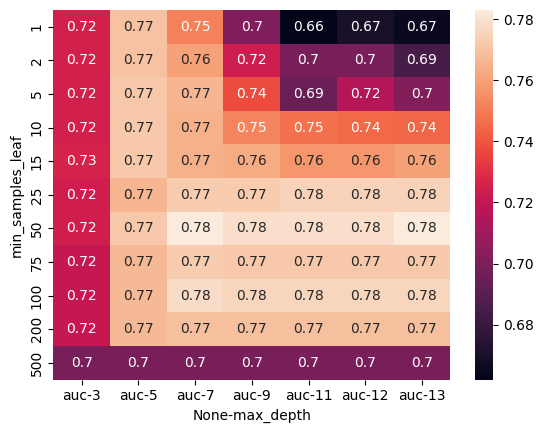

In [78]:
sns.heatmap(df_scores_pivot, annot=True)

In [81]:
dt2 = DecisionTreeClassifier(max_depth=7, min_samples_leaf=50).fit(X_train, y_train)

y_pred = dt2.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_true=y_val, y_score=y_pred)
auc




0.7834447241092811

In [80]:
roc_auc_score?

Signature:
roc_auc_score(
    y_true,
    y_score,
    *,
    average='macro',
    sample_weight=None,
    max_fpr=None,
    multi_class='raise',
    labels=None,
)
Docstring:
Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC)     from prediction scores.

Note: this implementation can be used with binary, multiclass and
multilabel classification, but some restrictions apply (see Parameters).

Read more in the :ref:`User Guide <roc_metrics>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_classes)
    True labels or binary label indicators. The binary and multiclass cases
    expect labels with shape (n_samples,) while the multilabel case expects
    binary label indicators with shape (n_samples, n_classes).

y_score : array-like of shape (n_samples,) or (n_samples, n_classes)
    Target scores.

    * In the binary case, it corresponds to an array of shape
      `(n_samples,)`. Both probability estimates and non-thresholded
     

# 6.6 Ensembles and Random Forest
- Board of experts
- Ensembling models
- Random Forest - ensembling decision trees
- Tuning Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=25, random_state=1).fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_true=y_val, y_score=y_pred)
print(auc)

rf.predict_proba(X_val[0:5,])

array([[0.52, 0.48],
       [0.68, 0.32],
       [0.8 , 0.2 ],
       [0.84, 0.16],
       [0.76, 0.24]])

In [159]:
scores = []

for trees in range(10, 201, 10):
    for depths in [5, 9, 11, 12]:
        rf = RandomForestClassifier(n_estimators=trees, max_depth = depths, random_state=1).fit(X_train, y_train)
        
        y_pred = rf.predict_proba(X_val)[:,1]
        
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append((trees, depths, auc))
    


In [160]:
df_scores = pd.DataFrame(scores, columns=['trees','max_depth', 'auc'])
df_scores.sort_values(by='auc', ascending=False)
#df_scores.head(n=10)

,trees,max_depth,auc
59,150,12,0.827831
78,200,11,0.827660
58,150,11,0.827574
57,150,9,0.827397
50,130,11,0.827269
...,...,...,...
4,20,5,0.811962
0,10,5,0.811718
7,20,12,0.810017
1,10,9,0.808868


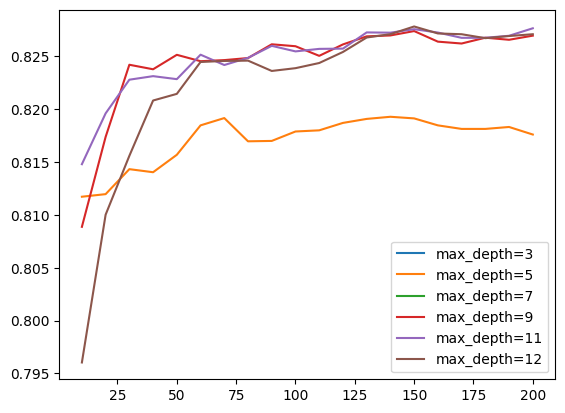

In [161]:
for depth in [3, 5, 7, 9, 11, 12]:
    df_subset = df_scores[df_scores.max_depth == depth]
    plt.plot(df_subset.trees, df_subset.auc, label ='max_depth=%d' % depth)
    
plt.legend()

In [163]:
max_depth = 12
trees = 150 

In [175]:
scores = []

for trees in range(10, 101, 10):
    for depths in [5, 9, 11, 12]:
        for s in [1, 3, 5, 10, 50]:
            
            rf = RandomForestClassifier(n_estimators=trees,  #number of trees
                                        max_depth = depths, #depth of tree 
                                        min_samples_leaf=s, #size of each group after splitting
                                        random_state=1).fit(X_train, y_train)
            
            y_pred = rf.predict_proba(X_val)[:,1]
            
            auc = roc_auc_score(y_val, y_pred)
            
            scores.append((trees, depths, s, auc))

In [176]:
df_scores = pd.DataFrame(scores, columns=['trees','max_depth', 'min_sample_leaf', 'auc'])
df_scores.sort_values(by='auc', ascending=False)

,trees,max_depth,min_sample_leaf,auc
27,20,9,5,0.831185
47,30,9,5,0.830745
187,100,9,5,0.830721
112,60,11,5,0.830647
167,90,9,5,0.830623
...,...,...,...,...
19,10,12,50,0.803061
14,10,11,50,0.803061
16,10,12,3,0.803019
3,10,5,10,0.802154


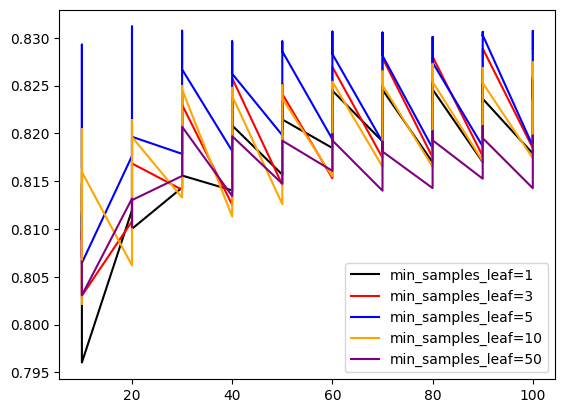

In [178]:
colors = ['black', 'red', 'blue', 'orange', 'purple']
min_sample_leaf_values = [1, 3, 5, 10, 50]
list(zip(colors, min_sample_leaf_values))


for s, col in zip(min_sample_leaf_values, colors):
    df_subset = df_scores[df_scores.min_sample_leaf == s]
    plt.plot(df_subset.trees, df_subset.auc, color = col,  
             label ='min_samples_leaf=%d' % s)
    
plt.legend()

In [185]:
chosen_max_depth = 9
chosen_trees = 20
chosen_min_samples_leaf = 5
#Retrain a final model with these parameters

rf_model = RandomForestClassifier(max_depth=chosen_max_depth,
                                  n_estimators = chosen_trees,
                                  min_samples_leaf = chosen_min_samples_leaf,
                                  n_jobs = -1,  #use all processors
                                  random_state=1).fit(X_train, y_train)

y_pred = rf_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, y_pred)
print(auc)


y_pred2 = rf_model.predict_proba(X_test)[:,1]
auc2 = roc_auc_score(y_test, y_pred2)
print(auc2)

0.8311849371975955
0.8266431924882629


## Other Useful Parameters

In [183]:
RandomForestClassifier?

# read more here ---> 
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

# 6.7 Gradient Boosting and XGBoost 
- It is the sequential training of decision trees or different way of combining trees to build a random forest
- Rf -> Train multiple independent decision trees and average their predictions
- Gradient Boost Trees -> Sequential training of trees such that the mistakes of the previous tree is corrected in the subsequent tree. \

To do:
- Gradient Boosting vs Random Forest
- Installing XGBoost
- Training the first model
- Performance Monitoring
- Parsing xgboost's monitoring output

In [187]:
#!pip install xgboost
import xgboost as xgb

In [ ]:
features = dv.get_feature_names_out().tolist()
features

xgb_train = xgb.DMatrix(data=X_train, label=y_train, feature_names=features) #dmatrix object for xgboost
xgb_val = xgb.DMatrix(data = X_val, label=y_val, feature_names=features)
xgb_test = xgb.DMatrix(X_test, label=y_test, feature_names=features)



#xgb.train?
#xgb.DMatrix?

In [205]:
xgb_params = {
    'eta': 0.3,  #lr - default is 0.3
    'max_depth': 6, # depth of tree
    'min_child_weight': 1, #same as min_samples_leaf
    
    'objective':'binary:logistic',  #classication problem 
    'nthread':8,  #parallelize 
    
    'seed':1,  #seed
    'verbosity':1,  #verbosity (0,1,2)
}


model = xgb.train(xgb_params, dtrain=xgb_train, num_boost_round= 10)

In [206]:
y_pred = model.predict(xgb_val)

roc_auc_score(y_val, y_pred)

0.8153988074874151

In [227]:
watchlist = [(xgb_train, 'train'), (xgb_val, 'val')]   #used to evaluate model during training

In [228]:
%%capture output 
xgb_params = {
    'eta': 0.3,  #lr - default is 0.3
    'max_depth': 6, # depth of tree
    'min_child_weight': 1, #same as min_samples_leaf
    
    'objective':'binary:logistic',  #classication problem 
    'eval_metric': 'auc',
    
    'nthread':8,  #parallelize 
    'seed':1,  #seed
    'verbosity':1,  #verbosity (0,1,2)
}

model = xgb.train(xgb_params, #tuning parameters
                  dtrain=xgb_train,
                  num_boost_round= 100, #trees to grow
                  verbose_eval = 10, # print evaluation at every 5 steps
                  evals=watchlist)

In [237]:
s= print(output.stdout)
print(s)

[0]	train-auc:0.86357	val-auc:0.78045
[10]	train-auc:0.95403	val-auc:0.81574
[20]	train-auc:0.97513	val-auc:0.82019
[30]	train-auc:0.98582	val-auc:0.81089
[40]	train-auc:0.99160	val-auc:0.80653
[50]	train-auc:0.99552	val-auc:0.80311
[60]	train-auc:0.99760	val-auc:0.80221
[70]	train-auc:0.99904	val-auc:0.79815
[80]	train-auc:0.99970	val-auc:0.79785
[90]	train-auc:0.99993	val-auc:0.79451
[99]	train-auc:0.99997	val-auc:0.79676

None


In [ ]:
#parse xgb output into a dataframe

def parse_xgb_output(output):
    results = []
    # tree = []
    # aucs_train = []
    # aucs_val = []
    
    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')
        
        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])
        
        
        # tree.append(it)
        # aucs_train.append(train)
        # auc_val.append(val_dicts)
        results.append((it, train, val))
        
    columns = ['num_iter', 'train_auc', 'val_auc'] 
    df_results = pd.DataFrame(results, columns=columns)
    return df_results #tree, aucs_train, aucs_val

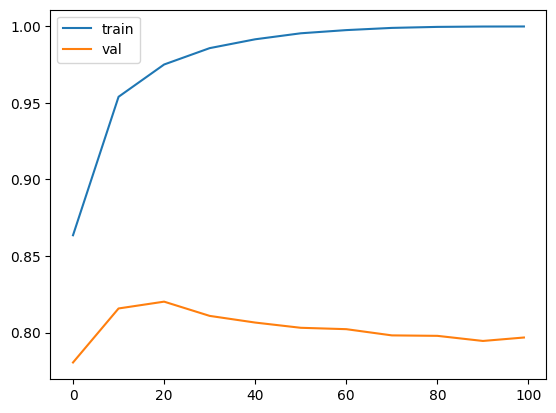

In [253]:
df_score = parse_xgb_output(output)
df_score

plt.plot(df_score.num_iter, df_score.train_auc, label = 'train')
plt.plot(df_score.num_iter,  df_score.val_auc, label = 'val')
plt.legend()


# 6.8 XGBoost Parameter Tuning 
Tuning the following parameters
- eta (learning rate)
- max_depth
- min_child_weight
